# QCredit: Credit Portfolio Optimization with QAOA and Qiskit

This notebook presents a didactic implementation of the **Quantum Approximate Optimization Algorithm (QAOA)** applied to the QCredit problem. The goal is to select a portfolio of customers for credit allocation while maximizing risk-adjusted return and respecting global budget and risk constraints.

The original project structure is preserved: first we define the business problem, then formulate the cost function mathematically, convert that function into a quantum Hamiltonian, build the circuit with Qiskit's `QAOAAnsatz`, optimize the variational parameters, and finally interpret measured bitstrings as classical credit decisions.

> **Core idea:** each customer is represented by a binary variable. If the bit is $1$, the customer is selected; if it is $0$, the customer is not selected. QAOA produces a distribution of candidate solutions, which is evaluated after simulated shot-based measurements.

> **Portfolio note:** This is an educational and experimental implementation. The six-customer instance is intentionally small so that exact classical enumeration can be used as a benchmark. It is not intended for real-world credit decisioning.


## 1. Environment Requirements

Run the cell below to ensure that the required libraries are available. The notebook uses `qiskit`, `qiskit-aer`, `numpy`, `pandas`, `matplotlib`, and `scipy`.

The implementation uses `QAOAAnsatz`, which builds the variational circuit from a `SparsePauliOp` cost operator.

In [ ]:
# Safe installation for execution in Google Colab.
import importlib.util
import subprocess
import sys

dependencias = {
    "qiskit": "qiskit",
    "qiskit_aer": "qiskit-aer",
    "scipy": "scipy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}

pacotes_ausentes = [
    nome_pip
    for nome_importacao, nome_pip in dependencias.items()
    if importlib.util.find_spec(nome_importacao) is None
]

if pacotes_ausentes:
    print("Installing missing packages:", pacotes_ausentes)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pacotes_ausentes])
else:
    print("Environment already contains the required libraries.")


Ambiente já contém as bibliotecas necessárias.


## 2. Library Imports

The libraries are separated by purpose. `numpy` and `pandas` handle the data; `matplotlib` generates visualizations; `SparsePauliOp` represents the Hamiltonian; `QAOAAnsatz` builds the QAOA circuit; and `Statevector` allows the expected value to be evaluated exactly for this small instance.

In [ ]:
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.sparse import SparseEfficiencyWarning

import qiskit
from qiskit import transpile
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp, Statevector

try:
    from qiskit_aer import AerSimulator
    SIMULADOR_AER_DISPONIVEL = True
except Exception:
    SIMULADOR_AER_DISPONIVEL = False

# Prevent internal sparse-matrix warnings from cluttering the Colab output.
warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)

np.set_printoptions(precision=4, suppress=True)
print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer available:", SIMULADOR_AER_DISPONIVEL)


Versão do Qiskit: 2.4.2
Qiskit Aer disponível: True


## 3. The QCredit Problem

QCredit is modeled as a customer-selection decision problem. For each customer, the team knows a credit limit, expected return, expected risk, and business segment. The decision is binary:

$$
x_i =
\begin{cases}
1, & \text{if customer } i \text{ is selected;} \\
0, & \text{otherwise.}
\end{cases}
$$

The portfolio must balance three criteria. First, we want to select customers with good expected return. Second, expected risk is discounted because high return combined with high risk may not be a desirable decision. Third, the portfolio should not exceed global budget and risk limits.

In [ ]:
dados_clientes_credito = pd.DataFrame({
    "cliente": ["C1", "C2", "C3", "C4", "C5", "C6"],
    "limite_credito": [3500, 2200, 5000, 1800, 3100, 1600],
    "retorno_esperado": [980, 610, 1420, 520, 870, 430],
    "risco_esperado": [420, 260, 620, 210, 390, 180],
    "segmento": ["A", "B", "A", "C", "B", "C"],
})

dados_clientes_credito.index.name = "indice_cliente"
dados_clientes_credito


,cliente,limite_credito,retorno_esperado,risco_esperado,segmento
indice_cliente,,,,,
0,C1,3500,980,420,A
1,C2,2200,610,260,B
2,C3,5000,1420,620,A
3,C4,1800,520,210,C
4,C5,3100,870,390,B
5,C6,1600,430,180,C


### 3.1 Data Interpretation

The `limite_credito` field represents the budget consumed when a customer enters the portfolio. `retorno_esperado` represents expected economic return. `risco_esperado` represents a measure of risk exposure. `segmento` is a categorical variable used to interpret the portfolio, although this basic version does not impose a direct constraint on it.

| Field | Role in the model | Used in the cost function? |
|---|---|---|
| `limite_credito` | Portfolio budget consumption | Yes, in the budget constraint |
| `retorno_esperado` | Expected benefit | Yes, as a maximization term |
| `risco_esperado` | Risk exposure | Yes, as a discount and constraint |
| `segmento` | Qualitative classification | Not directly in this version |

## 4. Business Parameters and Calibration

The parameters below define the selection policy. They are not internal parameters of `QAOAAnsatz`; they belong to the classical problem formulation and are later incorporated into the cost Hamiltonian.

| Code variable | Meaning | Base value |
|---|---|---:|
| `limite_orcamento_carteira` | Maximum allowed sum of credit limits | 9,500 |
| `limite_risco_carteira` | Maximum allowed total expected risk | 1,250 |
| `peso_aversao_risco` | Risk-aversion weight in net return | 0.40 |
| `peso_penalidade_orcamento` | Quadratic penalty for exceeding budget | 0.020 |
| `peso_penalidade_risco` | Quadratic penalty for exceeding risk | 0.120 |

In [ ]:
limite_orcamento_carteira = 9500
limite_risco_carteira = 1250
peso_aversao_risco = 0.40
peso_penalidade_orcamento = 0.020
peso_penalidade_risco = 0.120

politica_credito_base = {
    "limite_orcamento_carteira": limite_orcamento_carteira,
    "limite_risco_carteira": limite_risco_carteira,
    "peso_aversao_risco": peso_aversao_risco,
    "peso_penalidade_orcamento": peso_penalidade_orcamento,
    "peso_penalidade_risco": peso_penalidade_risco,
}

politica_credito_base


{'limite_orcamento_carteira': 9500,
 'limite_risco_carteira': 1250,
 'peso_aversao_risco': 0.4,
 'peso_penalidade_orcamento': 0.02,
 'peso_penalidade_risco': 0.12}

## 5. Mathematical Formulation of the Cost Function

Portfolio net return is defined as expected return minus a proportional risk discount:

$$
\text{net value}(x) = \sum_i x_i \cdot \left( return_i - \lambda_{risk} \cdot risk_i \right)
$$

Because Hamiltonian-based optimization is normally formulated as an **energy minimization** problem, we convert net-value maximization into minimization of its negative. We then add penalties when the portfolio violates the maximum budget or risk:

$$
C(x) = -\text{net value}(x)
+ p_{budget}\cdot \max(0, \text{credit}(x)-B)^2
+ p_{risk}\cdot \max(0, \text{risk}(x)-R)^2
$$

Here, $B$ corresponds to `limite_orcamento_carteira`, $R$ corresponds to `limite_risco_carteira`, $p_{budget}$ is `peso_penalidade_orcamento`, and $p_{risk}$ is `peso_penalidade_risco`. QAOA seeks to increase the occurrence of bitstrings with low cost $C(x)$ in the measurement distribution.

In [ ]:
limites_credito_clientes = dados_clientes_credito["limite_credito"].to_numpy(dtype=float)
retornos_esperados_clientes = dados_clientes_credito["retorno_esperado"].to_numpy(dtype=float)
riscos_esperados_clientes = dados_clientes_credito["risco_esperado"].to_numpy(dtype=float)
quantidade_clientes = len(dados_clientes_credito)


def avaliar_carteira_credito(decisoes_clientes, *, normalizar_custo=False, escala_normalizacao=1.0):
    """Evaluate a binary QCredit portfolio.

    Args:
        decisoes_clientes: 0/1 vector; 1 indicates a selected customer.
        normalizar_custo: if True, divide the cost by the provided scale.
        escala_normalizacao: factor used to normalize the cost.

    Returns:
        Dictionary with financial metrics, constraints, and portfolio cost.
    """
    decisoes_clientes = np.asarray(decisoes_clientes, dtype=int)

    credito_total = float(np.dot(decisoes_clientes, limites_credito_clientes))
    retorno_total = float(np.dot(decisoes_clientes, retornos_esperados_clientes))
    risco_total = float(np.dot(decisoes_clientes, riscos_esperados_clientes))
    valor_liquido = float(
        np.dot(
            decisoes_clientes,
            retornos_esperados_clientes - peso_aversao_risco * riscos_esperados_clientes,
        )
    )

    violacao_orcamento = max(0.0, credito_total - limite_orcamento_carteira)
    violacao_risco = max(0.0, risco_total - limite_risco_carteira)

    custo_original = (
        -valor_liquido
        + peso_penalidade_orcamento * violacao_orcamento**2
        + peso_penalidade_risco * violacao_risco**2
    )

    custo_calculado = custo_original / escala_normalizacao if normalizar_custo else custo_original

    return {
        "bitstring_clientes": "".join(map(str, decisoes_clientes)),
        "credito_total": credito_total,
        "retorno_total": retorno_total,
        "risco_total": risco_total,
        "valor_liquido": valor_liquido,
        "violacao_orcamento": violacao_orcamento,
        "violacao_risco": violacao_risco,
        "viavel": (violacao_orcamento == 0.0 and violacao_risco == 0.0),
        "custo": float(custo_calculado),
        "custo_original": float(custo_original),
    }


# Example: portfolio selecting C1, C3, and C6.
avaliar_carteira_credito([1, 0, 1, 0, 0, 1])


{'bitstring_clientes': '101001',
 'credito_total': 10100.0,
 'retorno_total': 2830.0,
 'risco_total': 1220.0,
 'valor_liquido': 2342.0,
 'violacao_orcamento': 600.0,
 'violacao_risco': 0.0,
 'viavel': False,
 'custo': 4858.0,
 'custo_original': 4858.0}

## 6. Exact Classical Enumeration as a Reference

Because the instance contains only six customers, there are $2^6 = 64$ possible portfolios. We can evaluate all of them to obtain the exact classical optimum. This step provides a **validation reference** for the experiment: the QAOA recommendation is obtained only from states actually observed in the final measurement stage.

In [ ]:
avaliacoes_carteiras = []

for decisoes_clientes in itertools.product([0, 1], repeat=quantidade_clientes):
    avaliacoes_carteiras.append(avaliar_carteira_credito(decisoes_clientes))

ranking_classico_carteiras = (
    pd.DataFrame(avaliacoes_carteiras)
    .sort_values("custo_original", ascending=True)
    .reset_index(drop=True)
)

ranking_classico_carteiras.head(10)


,bitstring_clientes,credito_total,retorno_total,risco_total,valor_liquido,violacao_orcamento,violacao_risco,viavel,custo,custo_original
0,011100,9000.0,2550.0,1090.0,2114.0,0.0,0.0,True,-2114.0,-2114.0
1,110101,9100.0,2540.0,1070.0,2112.0,0.0,0.0,True,-2112.0,-2112.0
2,011001,8800.0,2460.0,1060.0,2036.0,0.0,0.0,True,-2036.0,-2036.0
3,110010,8800.0,2460.0,1070.0,2032.0,0.0,0.0,True,-2032.0,-2032.0
4,010111,8700.0,2430.0,1040.0,2014.0,0.0,0.0,True,-2014.0,-2014.0
5,101000,8500.0,2400.0,1040.0,1984.0,0.0,0.0,True,-1984.0,-1984.0
6,001101,8400.0,2370.0,1010.0,1966.0,0.0,0.0,True,-1966.0,-1966.0
7,100110,8400.0,2370.0,1020.0,1962.0,0.0,0.0,True,-1962.0,-1962.0
8,001010,8100.0,2290.0,1010.0,1886.0,0.0,0.0,True,-1886.0,-1886.0
9,100011,8200.0,2280.0,990.0,1884.0,0.0,0.0,True,-1884.0,-1884.0


In [ ]:
melhor_carteira_global = ranking_classico_carteiras.iloc[0]
carteiras_viaveis_referencia = (
    ranking_classico_carteiras[ranking_classico_carteiras["viavel"]]
    .sort_values("custo_original", ascending=True)
)
melhor_carteira_viavel = carteiras_viaveis_referencia.iloc[0]

print("Best global classical portfolio:")
print(melhor_carteira_global.to_string())
print("\nBest feasible classical portfolio:")
print(melhor_carteira_viavel.to_string())


Melhor carteira clássica global:
bitstring_clientes    011100
credito_total         9000.0
retorno_total         2550.0
risco_total           1090.0
valor_liquido         2114.0
violacao_orcamento       0.0
violacao_risco           0.0
viavel                  True
custo                -2114.0
custo_original       -2114.0

Melhor carteira clássica viável:
bitstring_clientes    011100
credito_total         9000.0
retorno_total         2550.0
risco_total           1090.0
valor_liquido         2114.0
violacao_orcamento       0.0
violacao_risco           0.0
viavel                  True
custo                -2114.0
custo_original       -2114.0


## 7. Cost-Landscape Visualization

The first figure shows the cost of all 64 portfolios, making the effect of penalties on infeasible solutions visible. The second figure shows only feasible portfolios, providing a clearer comparison among solutions that satisfy the credit policy.

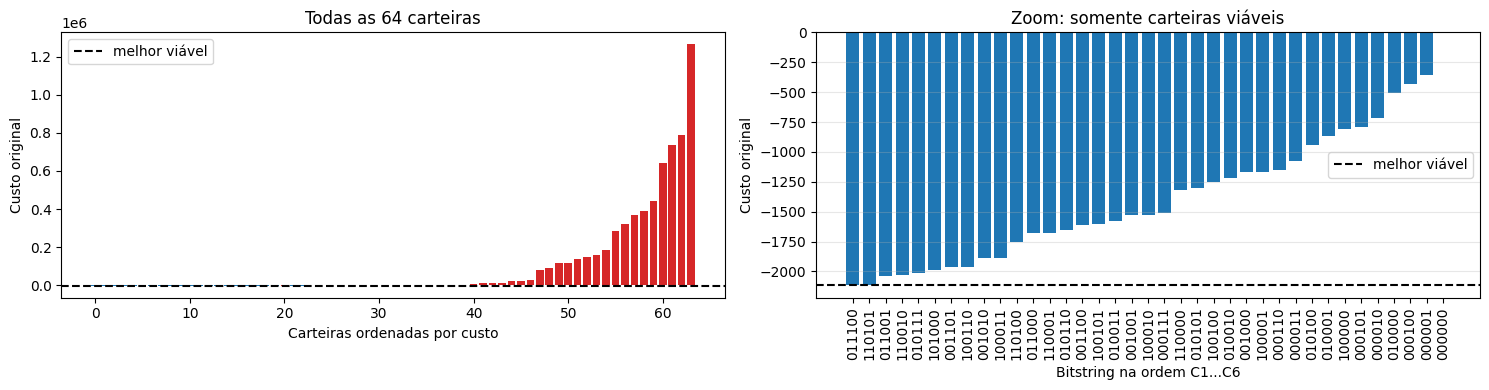

In [ ]:
dados_grafico_custos = ranking_classico_carteiras.copy()
dados_grafico_custos["posicao_ranking"] = np.arange(len(dados_grafico_custos))
cores_viabilidade = np.where(dados_grafico_custos["viavel"], "tab:blue", "tab:red")

figura, (eixo_todas, eixo_viaveis) = plt.subplots(1, 2, figsize=(15, 4))

eixo_todas.bar(
    dados_grafico_custos["posicao_ranking"],
    dados_grafico_custos["custo_original"],
    color=cores_viabilidade,
)
eixo_todas.axhline(
    melhor_carteira_viavel["custo_original"],
    linestyle="--",
    color="black",
    label="best feasible",
)
eixo_todas.set_title("All 64 portfolios")
eixo_todas.set_xlabel("Portfolios ordered by cost")
eixo_todas.set_ylabel("Original cost")
eixo_todas.legend()

dados_viaveis_grafico = carteiras_viaveis_referencia.reset_index(drop=True).copy()
eixo_viaveis.bar(
    dados_viaveis_grafico["bitstring_clientes"],
    dados_viaveis_grafico["custo_original"],
    color="tab:blue",
)
eixo_viaveis.axhline(
    melhor_carteira_viavel["custo_original"],
    linestyle="--",
    color="black",
    label="best feasible",
)
eixo_viaveis.set_title("Zoom: feasible portfolios only")
eixo_viaveis.set_xlabel("Bitstring in C1...C6 order")
eixo_viaveis.set_ylabel("Original cost")
eixo_viaveis.tick_params(axis="x", rotation=90)
eixo_viaveis.grid(axis="y", alpha=0.3)
eixo_viaveis.legend()

plt.tight_layout()
plt.show()


## 8. From the Classical Problem to the Quantum Hamiltonian

QAOA requires a diagonal cost operator. Each bitstring $x$ must correspond to an energy $C(x)$. Lower-energy states represent better solutions.

To transform the classical function into a Hamiltonian, we use spin variables:

$$
z_i \in \{-1, +1\}, \quad x_i = \frac{1-z_i}{2}
$$

We then express the cost function as a sum of products of $z_i$ variables:

$$
C(z) = c_0 + \sum_i c_i z_i + \sum_{i<j} c_{ij} z_i z_j + \cdots
$$

In [ ]:
# Normalization prevents excessively large coefficients in the cost operator.
custos_originais_carteiras = ranking_classico_carteiras["custo_original"].to_numpy()
escala_normalizacao_custo = max(1.0, np.max(np.abs(custos_originais_carteiras)))
print("Cost scale used for normalization:", escala_normalizacao_custo)


def calcular_custo_normalizado(decisoes_clientes):
    return avaliar_carteira_credito(
        decisoes_clientes,
        normalizar_custo=True,
        escala_normalizacao=escala_normalizacao_custo,
    )["custo"]


def construir_hamiltoniano_diagonal(funcao_custo, quantidade_qubits, tolerancia=1e-10):
    """
    Constrói Hamiltoniano diagonal pela expansão completa em produtos de Pauli Z.
    A expansão é apropriada para esta instância pequena. Para uma aplicação maior,
    seria necessário estudar uma formulação QUBO/Ising mais escalável.
    """
    termos_operador_pauli = []
    termo_constante = 0.0

    for mascara_pauli in range(2**quantidade_qubits):
        coeficiente = 0.0

        for spins_z in itertools.product([1, -1], repeat=quantidade_qubits):
            decisoes_clientes = np.array([(1 - spin) // 2 for spin in spins_z], dtype=int)
            produto_spins = 1.0

            for indice_qubit in range(quantidade_qubits):
                if (mascara_pauli >> indice_qubit) & 1:
                    produto_spins *= spins_z[indice_qubit]

            # Sum over all spin combinations to compute the Walsh-Hadamard transform, yielding the Pauli coefficient.
            coeficiente += funcao_custo(decisoes_clientes) * produto_spins

        coeficiente /= 2**quantidade_qubits

        if abs(coeficiente) > tolerancia:
            if mascara_pauli == 0:
                termo_constante = float(coeficiente)
            else:
                rotulos_pauli = ["I"] * quantidade_qubits

                for indice_qubit in range(quantidade_qubits):
                    if (mascara_pauli >> indice_qubit) & 1:
                        rotulos_pauli[indice_qubit] = "Z"

                # Qiskit uses little-endian order; the string is reversed to preserve C1...C6 order.
                termos_operador_pauli.append(("".join(rotulos_pauli)[::-1], float(coeficiente)))

    hamiltoniano_custo = SparsePauliOp.from_list(termos_operador_pauli).simplify()
    return hamiltoniano_custo, termo_constante, termos_operador_pauli


hamiltoniano_custo, termo_constante, termos_pauli_custo = construir_hamiltoniano_diagonal(
    calcular_custo_normalizado,
    quantidade_clientes,
)

print("Number of qubits:", quantidade_clientes)
print("Number of non-constant Pauli terms:", len(termos_pauli_custo))
print("Constant term:", termo_constante)
print(hamiltoniano_custo)


Escala de custo usada para normalização: 1264470.0
Número de qubits: 6
Número de termos de Pauli sem contar o termo constante: 63
Termo constante: 0.0783365263707324
SparsePauliOp(['IIIIIZ', 'IIIIZI', 'IIIIZZ', 'IIIZII', 'IIIZIZ', 'IIIZZI', 'IIIZZZ', 'IIZIII', 'IIZIIZ', 'IIZIZI', 'IIZIZZ', 'IIZZII', 'IIZZIZ', 'IIZZZI', 'IIZZZZ', 'IZIIII', 'IZIIIZ', 'IZIIZI', 'IZIIZZ', 'IZIZII', 'IZIZIZ', 'IZIZZI', 'IZIZZZ', 'IZZIII', 'IZZIIZ', 'IZZIZI', 'IZZIZZ', 'IZZZII', 'IZZZIZ', 'IZZZZI', 'IZZZZZ', 'ZIIIII', 'ZIIIIZ', 'ZIIIZI', 'ZIIIZZ', 'ZIIZII', 'ZIIZIZ', 'ZIIZZI', 'ZIIZZZ', 'ZIZIII', 'ZIZIIZ', 'ZIZIZI', 'ZIZIZZ', 'ZIZZII', 'ZIZZIZ', 'ZIZZZI', 'ZIZZZZ', 'ZZIIII', 'ZZIIIZ', 'ZZIIZI', 'ZZIIZZ', 'ZZIZII', 'ZZIZIZ', 'ZZIZZI', 'ZZIZZZ', 'ZZZIII', 'ZZZIIZ', 'ZZZIZI', 'ZZZIZZ', 'ZZZZII', 'ZZZZIZ', 'ZZZZZI', 'ZZZZZZ'],
              coeffs=[-0.0609+0.j, -0.0407+0.j,  0.0264+0.j, -0.0746+0.j,  0.0563+0.j,
  0.0363+0.j, -0.0218+0.j, -0.0336+0.j,  0.0217+0.j,  0.014 +0.j,
 -0.0061+0.j,  0.0297+0.j, -0.0176+

### 8.1 Hamiltonian Verification

Before using the Hamiltonian in QAOA, we verify that it reproduces the classical cost function for every bitstring. Because the constant term `termo_constante` does not affect optimization, it is kept separately and added back when comparing the complete numerical cost.

In [ ]:
def calcular_energia_bitstring(decisoes_clientes):
    """Calculate the diagonal Hamiltonian energy for a classical portfolio."""
    decisoes_clientes = np.asarray(decisoes_clientes, dtype=int)
    spins_z = 1 - 2 * decisoes_clientes
    energia = termo_constante

    for rotulo_pauli, coeficiente in termos_pauli_custo:
        rotulo_ordem_clientes = rotulo_pauli[::-1]
        produto_spins = 1.0

        for indice_cliente, operador in enumerate(rotulo_ordem_clientes):
            if operador == "Z":
                produto_spins *= spins_z[indice_cliente]

        energia += coeficiente * produto_spins

    return float(np.real(energia))


maior_erro_reconstrucao = 0.0

for decisoes_clientes in itertools.product([0, 1], repeat=quantidade_clientes):
    erro_reconstrucao = abs(
        calcular_energia_bitstring(decisoes_clientes)
        - calcular_custo_normalizado(decisoes_clientes)
    )
    maior_erro_reconstrucao = max(maior_erro_reconstrucao, erro_reconstrucao)

print("Maximum reconstruction error:", maior_erro_reconstrucao)
assert maior_erro_reconstrucao < 1e-8


Maior erro de reconstrução: 5.551115123125783e-16


## 9. Building the QAOA Circuit with `QAOAAnsatz`

`QAOAAnsatz` receives the cost Hamiltonian and builds a parameterized circuit with alternating layers. Each layer uses two types of parameters:

$$
\gamma_k \quad \text{for the cost operator},
$$

$$
\beta_k \quad \text{for the mixer operator}.
$$

`QAOAAnsatz` uses an RX-based mixer by default, with rotations applied to each qubit. This is a common choice for binary optimization problems.

The number of repetitions $reps = p$ controls circuit depth. Increasing $p$ generally increases expressiveness, but also increases the number of parameters and optimization difficulty.

In [ ]:
numero_camadas_qaoa = 2
circuito_qaoa = QAOAAnsatz(cost_operator=hamiltoniano_custo, reps=numero_camadas_qaoa)
parametros_variacionais = list(circuito_qaoa.parameters)

print(circuito_qaoa)
print("\nCircuit parameters:")
print(parametros_variacionais)
print("Number of parameters:", len(parametros_variacionais))
print("Number of qubits:", circuito_qaoa.num_qubits)


     ┌────────────────────────────┐
q_0: ┤0                           ├
     │                            │
q_1: ┤1                           ├
     │                            │
q_2: ┤2                           ├
     │  QAOA(γ[0],β[0],γ[1],β[1]) │
q_3: ┤3                           ├
     │                            │
q_4: ┤4                           ├
     │                            │
q_5: ┤5                           ├
     └────────────────────────────┘

Parâmetros do circuito:
[ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])]
Número de parâmetros: 4
Número de qubits: 6


In [ ]:
# Text drawing: keeps compatibility with Colab without additional visualization dependencies.
circuito_qaoa.decompose(reps=1).draw("text")


┌───┐»
q_0: ┤ H ├»
     ├───┤»
q_1: ┤ H ├»
     ├───┤»
q_2: ┤ H ├»
     ├───┤»
q_3: ┤ H ├»
     ├───┤»
q_4: ┤ H ├»
     ├───┤»
q_5: ┤ H ├»
     └───┘»
«     ┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«q_0: ┤0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       ├»
«     │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        │»
«q_1: ┤1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       ├»
«     │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        │»
«q_2: ┤2                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       ├»
«     │  exp(-it (IIIIIZ + IIIIZI + IIIIZZ + IIIZII + IIIZIZ + IIIZZI + IIIZZZ + IIZIII + IIZIIZ + IIZIZI + IIZIZZ + IIZZII + IIZZIZ + IIZZZI + IIZZZZ + IZIIII + IZIIIZ + IZIIZI + IZIIZZ + IZIZII + IZIZIZ + IZIZZI + IZIZZZ + IZZIII + IZZIIZ + IZZIZI + IZZIZZ + IZZZII + IZZZIZ + IZZZZI

## 10. Variational Objective Function

The hybrid QAOA stage adjusts the $\beta$ and $\gamma$ parameters to minimize the expected value of the cost Hamiltonian:

$$
\langle H_C \rangle = \langle \psi(\beta,\gamma) | H_C | \psi(\beta,\gamma) \rangle
$$

In this didactic implementation, `Statevector` is used to calculate this expectation value exactly in simulation. On real quantum hardware or in a shot-based simulator, this value would be estimated from measurements.

In [ ]:
historico_custo_esperado = []

def montar_circuito_com_parametros(valores_parametros):
    mapeamento_parametros = {
        parametro: valor
        for parametro, valor in zip(parametros_variacionais, valores_parametros)
    }
    return circuito_qaoa.assign_parameters(mapeamento_parametros, inplace=False)


def calcular_objetivo_qaoa(valores_parametros):
    circuito_parametrizado = montar_circuito_com_parametros(valores_parametros)
    estado_quantico = Statevector.from_instruction(circuito_parametrizado)
    energia_esperada = np.real(estado_quantico.expectation_value(hamiltoniano_custo))
    historico_custo_esperado.append(float(energia_esperada + termo_constante))
    return float(energia_esperada)


# Teste da função objetivo com parâmetros iniciais simples.
parametros_teste = np.array([0.5] * len(parametros_variacionais))
print(
    "Test normalized expected cost:",
    calcular_objetivo_qaoa(parametros_teste) + termo_constante,
)


Custo esperado normalizado de teste: 0.11849895139585626


## 11. Classical Optimization of QAOA Parameters

QAOA is hybrid: the quantum circuit depends on parameters, while a classical optimizer proposes new values. Multiple starting points are used to reduce the chance of getting trapped in an unfavorable region of the optimization landscape.

The QAOA parameters are angular. In this didactic implementation, bounds between $0$ and $\pi$ are used, preserving the original experimental configuration.

In [ ]:
gerador_aleatorio = np.random.default_rng(42)
quantidade_reinicios = 5
limites_parametros = [(0.0, np.pi)] * len(parametros_variacionais)
melhor_otimizacao = None
resultados_por_reinicio = []
intervalos_historico_reinicios = []

parametros_iniciais = [np.full(len(parametros_variacionais), 0.5)]
parametros_iniciais += [
    gerador_aleatorio.uniform(0, np.pi, size=len(parametros_variacionais))
    for _ in range(quantidade_reinicios - 1)
]

for numero_rodada, parametros_iniciais_rodada in enumerate(parametros_iniciais, start=1):
    print(f"Run {numero_rodada}: initial parameters =", np.round(parametros_iniciais_rodada, 4))
    inicio_historico = len(historico_custo_esperado)

    resultado_rodada = minimize(
        calcular_objetivo_qaoa,
        parametros_iniciais_rodada,
        method="Powell",
        bounds=limites_parametros,
        options={"maxiter": 80, "xtol": 1e-3, "ftol": 1e-3, "disp": False},
    )

    fim_historico = len(historico_custo_esperado)
    intervalos_historico_reinicios.append((inicio_historico, fim_historico))
    resultados_por_reinicio.append(resultado_rodada)

    if melhor_otimizacao is None or resultado_rodada.fun < melhor_otimizacao.fun:
        melhor_otimizacao = resultado_rodada

print("\nBest result found:")
print("success:", melhor_otimizacao.success)
print("normalized expected cost:", melhor_otimizacao.fun + termo_constante)
print("optimal parameters:", np.round(melhor_otimizacao.x, 6))


Rodada 1: parâmetros iniciais = [0.5 0.5 0.5 0.5]
Rodada 2: parâmetros iniciais = [2.4315 1.3788 2.6974 2.1908]
Rodada 3: parâmetros iniciais = [0.2959 3.065  2.3912 2.4695]
Rodada 4: parâmetros iniciais = [0.4025 1.4149 1.1649 2.9115]
Rodada 5: parâmetros iniciais = [2.0228 2.5848 1.393  0.7139]

Melhor resultado encontrado:
sucesso: True
custo esperado normalizado: 0.006705043967315569
parâmetros ótimos: [2.8253 2.9673 1.6222 3.1416]


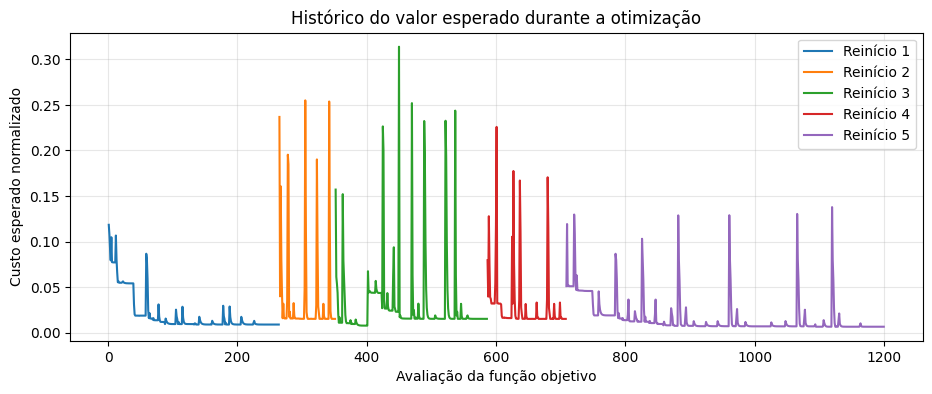

In [ ]:
plt.figure(figsize=(11, 4))

for numero_rodada, (inicio_historico, fim_historico) in enumerate(intervalos_historico_reinicios, start=1):
    avaliacoes_rodada = range(inicio_historico, fim_historico)
    custos_rodada = historico_custo_esperado[inicio_historico:fim_historico]
    plt.plot(avaliacoes_rodada, custos_rodada, label=f"Restart {numero_rodada}")

plt.title("Expected-value history during optimization")
plt.xlabel("Objective-function evaluation")
plt.ylabel("Normalized expected cost")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 12. Sampling the Final Distribution

After optimizing the parameters, the circuit is executed one final time. Exact `Statevector` probabilities are retained only as diagnostics for this small instance.

To produce the experimental QAOA output, `4000` simulated measurements are performed. When available, `AerSimulator` executes the measured circuit, following the approach used in the course notebook; otherwise, measurements are sampled from the `Statevector` distribution. In both cases, the final recommendation considers only bitstrings actually observed in the measurements.

In [ ]:
circuito_qaoa_otimizado = montar_circuito_com_parametros(melhor_otimizacao.x)
estado_quantico_otimizado = Statevector.from_instruction(circuito_qaoa_otimizado)
probabilidades_exatas = estado_quantico_otimizado.probabilities_dict()

numero_medicoes = 4000

if SIMULADOR_AER_DISPONIVEL:
    simulador_medicoes = AerSimulator()
    circuito_com_medicao = circuito_qaoa_otimizado.measure_all(inplace=False)
    circuito_transpilado = transpile(circuito_com_medicao, simulador_medicoes)
    execucao_medicoes = simulador_medicoes.run(
        circuito_transpilado,
        shots=numero_medicoes,
        seed_simulator=42,
    ).result()
    contagens_medidas = execucao_medicoes.get_counts()
    metodo_amostragem = "AerSimulator"
else:
    gerador_medicoes = np.random.default_rng(42)
    estados_qiskit = np.array(list(probabilidades_exatas.keys()))
    vetor_probabilidades = np.array(
        [probabilidades_exatas[estado] for estado in estados_qiskit],
        dtype=float,
    )
    amostras = gerador_medicoes.choice(
        estados_qiskit,
        size=numero_medicoes,
        p=vetor_probabilidades,
    )
    contagens_medidas = pd.Series(amostras).value_counts().to_dict()
    metodo_amostragem = "random sampling from Statevector"


def converter_estado_qiskit_para_decisoes(bitstring_qiskit):
    # Convert Qiskit little-endian order to logical C1...C6 order
    return np.array([int(bit) for bit in bitstring_qiskit[::-1]], dtype=int)

avaliacoes_amostradas_qaoa = []

for bitstring_qiskit, contagem in contagens_medidas.items():
    decisoes_clientes = converter_estado_qiskit_para_decisoes(bitstring_qiskit)
    avaliacao_medida = avaliar_carteira_credito(decisoes_clientes)
    avaliacao_medida["bitstring_qiskit"] = bitstring_qiskit
    avaliacao_medida["contagem"] = int(contagem)
    avaliacao_medida["frequencia_amostrada"] = float(contagem / numero_medicoes)
    avaliacao_medida["probabilidade_exata"] = float(probabilidades_exatas.get(bitstring_qiskit, 0.0))
    avaliacoes_amostradas_qaoa.append(avaliacao_medida)

resultados_amostrados_qaoa = (
    pd.DataFrame(avaliacoes_amostradas_qaoa)
    .sort_values(["contagem", "custo_original"], ascending=[False, True])
    .reset_index(drop=True)
)

estado_mais_frequente_qaoa = resultados_amostrados_qaoa.iloc[0]

print("Measurement method:", metodo_amostragem)
print("Total measurements:", sum(contagens_medidas.values()))
print("Distinct observed states:", len(resultados_amostrados_qaoa))
resultados_amostrados_qaoa.head(25)


Método de medição: AerSimulator
Total de medições: 4000
Estados distintos observados: 62


,bitstring_clientes,credito_total,retorno_total,risco_total,valor_liquido,violacao_orcamento,violacao_risco,viavel,custo,custo_original,bitstring_qiskit,contagem,frequencia_amostrada,probabilidade_exata
0,001001,6600.0,1850.0,800.0,1530.0,0.0,0.0,True,-1530.0,-1530.0,100100,123,0.03075,0.025403
1,001010,8100.0,2290.0,1010.0,1886.0,0.0,0.0,True,-1886.0,-1886.0,010100,117,0.02925,0.026691
2,101000,8500.0,2400.0,1040.0,1984.0,0.0,0.0,True,-1984.0,-1984.0,000101,113,0.02825,0.027391
3,001100,6800.0,1940.0,830.0,1608.0,0.0,0.0,True,-1608.0,-1608.0,001100,106,0.02650,0.025599
4,100001,5100.0,1410.0,600.0,1170.0,0.0,0.0,True,-1170.0,-1170.0,100001,105,0.02625,0.023475
5,100100,5300.0,1500.0,630.0,1248.0,0.0,0.0,True,-1248.0,-1248.0,001001,104,0.02600,0.023645
6,010010,5300.0,1480.0,650.0,1220.0,0.0,0.0,True,-1220.0,-1220.0,010010,102,0.02550,0.023471
7,010101,5600.0,1560.0,650.0,1300.0,0.0,0.0,True,-1300.0,-1300.0,101010,101,0.02525,0.022312
8,000110,4900.0,1390.0,600.0,1150.0,0.0,0.0,True,-1150.0,-1150.0,011000,101,0.02525,0.023110
9,110000,5700.0,1590.0,680.0,1318.0,0.0,0.0,True,-1318.0,-1318.0,000011,98,0.02450,0.023906


/tmp/ipykernel_7655/2675149370.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


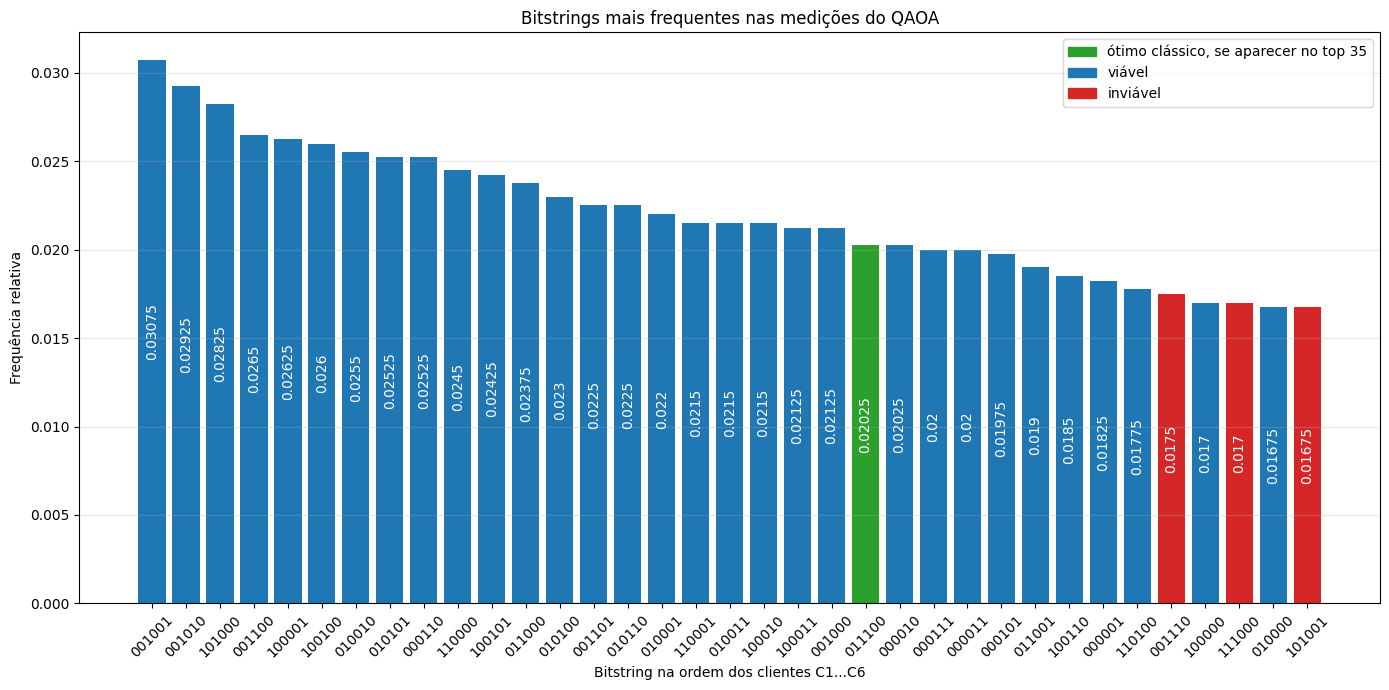

In [ ]:
from matplotlib.patches import Patch

estados_mais_frequentes = resultados_amostrados_qaoa.head(35).copy()
bitstring_otimo_classico = melhor_carteira_viavel["bitstring_clientes"]

cores_estados = [
    "tab:green" if linha["bitstring_clientes"] == bitstring_otimo_classico
    else "tab:blue" if linha["viavel"]
    else "tab:red"
    for _, linha in estados_mais_frequentes.iterrows()
]

plt.figure(figsize=(14, 7), layout="constrained")
barras = plt.bar(
    estados_mais_frequentes["bitstring_clientes"],
    estados_mais_frequentes["frequencia_amostrada"],
    color=cores_estados,
)
plt.title("Most frequent bitstrings in QAOA measurements")
plt.xlabel("Bitstring in C1...C6 customer order")
plt.ylabel("Relative frequency")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(handles=[
    Patch(color="tab:green", label="classical optimum, if present in top 35"),
    Patch(color="tab:blue", label="feasible"),
    Patch(color="tab:red", label="infeasible"),
])
plt.bar_label(barras, label_type='center', rotation=90, color='white')
plt.tight_layout()
plt.show()


## 13. Post-Processing: From Bitstring to Credit Decision

The quantum result must be translated back into a business recommendation. In this corrected version, we filter **only portfolios actually observed in the measurements** and select, among the observed feasible portfolios, the one with the lowest original cost. The table also separates the most frequent state from the best measured solution, avoiding the claim that QAOA concentrated probability on the optimum merely because the optimum appeared in the sample.

Because the instance contains only 64 combinations and many measurements are used, a large portion of the solution space can be observed. For larger problems, this coverage is no longer feasible.

In a production setting, this stage would also require credit governance, regulatory validation, explainability analysis, and expert review.

In [ ]:
carteiras_viaveis_medidas = resultados_amostrados_qaoa[resultados_amostrados_qaoa["viavel"]].copy()

if len(carteiras_viaveis_medidas) == 0:
    print("No feasible portfolio was observed. Consider increasing the number of measurements or recalibrating the penalties.")
    melhor_carteira_qaoa_medida = estado_mais_frequente_qaoa
else:
    melhor_carteira_qaoa_medida = (
        carteiras_viaveis_medidas
        .sort_values(["custo_original", "contagem"], ascending=[True, False])
        .iloc[0]
    )

ocorrencias_otimo_classico = resultados_amostrados_qaoa[
    resultados_amostrados_qaoa["bitstring_clientes"] == melhor_carteira_viavel["bitstring_clientes"]
]
cobertura_espaco_solucoes = len(resultados_amostrados_qaoa) / (2**quantidade_clientes)

print("Most frequent measured state:")
print(estado_mais_frequente_qaoa[[
    "bitstring_clientes", "contagem", "frequencia_amostrada", "valor_liquido", "viavel"
]].to_string())

print("\nBest feasible portfolio among measurements:")
print(melhor_carteira_qaoa_medida[[
    "bitstring_clientes", "contagem", "frequencia_amostrada", "credito_total",
    "retorno_total", "risco_total", "valor_liquido", "viavel", "custo_original"
]].to_string())

print(f"\nObserved solution-space coverage: {cobertura_espaco_solucoes:.1%}")

if len(ocorrencias_otimo_classico) > 0:
    frequencia_otimo = ocorrencias_otimo_classico.iloc[0]["frequencia_amostrada"]
    print(f"Classical optimum observed in measurements: yes ({frequencia_otimo:.2%} of measurements)")
else:
    print("Classical optimum observed in measurements: no")

decisoes_carteira_qaoa = np.array(
    [int(bit) for bit in melhor_carteira_qaoa_medida["bitstring_clientes"]],
    dtype=int,
)
clientes_recomendados_qaoa = dados_clientes_credito[decisoes_carteira_qaoa == 1].copy()
clientes_recomendados_qaoa


Estado mais frequente medido:
bitstring_clientes       001001
contagem                    123
frequencia_amostrada    0.03075
valor_liquido            1530.0
viavel                     True

Melhor carteira viável entre as medições:
bitstring_clientes       011100
contagem                     81
frequencia_amostrada    0.02025
credito_total            9000.0
retorno_total            2550.0
risco_total              1090.0
valor_liquido            2114.0
viavel                     True
custo_original          -2114.0

Cobertura observada do espaço de soluções: 96.9%
Ótimo clássico observado nas medições: sim (2.02% das medições)


,cliente,limite_credito,retorno_esperado,risco_esperado,segmento
indice_cliente,,,,,
1,C2,2200,610,260,B
2,C3,5000,1420,620,A
3,C4,1800,520,210,C


In [ ]:
comparacao_resultados = pd.DataFrame([
    {
        "metodo": "Exact feasible classical optimum (reference)",
        "bitstring": melhor_carteira_viavel["bitstring_clientes"],
        "frequencia_amostrada": np.nan,
        "credito_total": melhor_carteira_viavel["credito_total"],
        "retorno_total": melhor_carteira_viavel["retorno_total"],
        "risco_total": melhor_carteira_viavel["risco_total"],
        "valor_liquido": melhor_carteira_viavel["valor_liquido"],
        "custo_original": melhor_carteira_viavel["custo_original"],
    },
    {
        "metodo": "Most frequent state measured by QAOA",
        "bitstring": estado_mais_frequente_qaoa["bitstring_clientes"],
        "frequencia_amostrada": estado_mais_frequente_qaoa["frequencia_amostrada"],
        "credito_total": estado_mais_frequente_qaoa["credito_total"],
        "retorno_total": estado_mais_frequente_qaoa["retorno_total"],
        "risco_total": estado_mais_frequente_qaoa["risco_total"],
        "valor_liquido": estado_mais_frequente_qaoa["valor_liquido"],
        "custo_original": estado_mais_frequente_qaoa["custo_original"],
    },
    {
        "metodo": "Best feasible portfolio observed in QAOA measurements",
        "bitstring": melhor_carteira_qaoa_medida["bitstring_clientes"],
        "frequencia_amostrada": melhor_carteira_qaoa_medida["frequencia_amostrada"],
        "credito_total": melhor_carteira_qaoa_medida["credito_total"],
        "retorno_total": melhor_carteira_qaoa_medida["retorno_total"],
        "risco_total": melhor_carteira_qaoa_medida["risco_total"],
        "valor_liquido": melhor_carteira_qaoa_medida["valor_liquido"],
        "custo_original": melhor_carteira_qaoa_medida["custo_original"],
    },
])

comparacao_resultados


,metodo,bitstring,frequencia_amostrada,credito_total,retorno_total,risco_total,valor_liquido,custo_original
0,Ótimo clássico viável (referência),011100,NaN,9000.0,2550.0,1090.0,2114.0,-2114.0
1,Estado mais frequente medido pelo QAOA,001001,0.03075,6600.0,1850.0,800.0,1530.0,-1530.0
2,Melhor viável observado nas medições QAOA,011100,0.02025,9000.0,2550.0,1090.0,2114.0,-2114.0


## 14. Sensitivity Analysis of Business Parameters

Portfolio quality depends on the parameters defined by the credit policy. To demonstrate this effect, three scenarios are tested:

| Scenario | Interpretation |
|---|---|
| Conservative | Higher risk aversion and lower maximum risk |
| Base | Parameters used in the main experiment |
| Aggressive | Lower risk aversion and higher risk tolerance |

This section uses exact classical enumeration to isolate the effect of business parameters without mixing the analysis with variations in QAOA optimization.

In [ ]:
def avaliar_carteira_em_cenario(decisoes_clientes, politica_credito):
    decisoes_clientes = np.asarray(decisoes_clientes, dtype=int)

    credito_total = float(np.dot(decisoes_clientes, limites_credito_clientes))
    retorno_total = float(np.dot(decisoes_clientes, retornos_esperados_clientes))
    risco_total = float(np.dot(decisoes_clientes, riscos_esperados_clientes))
    valor_liquido = float(
        np.dot(
            decisoes_clientes,
            retornos_esperados_clientes
            - politica_credito["peso_aversao_risco"] * riscos_esperados_clientes,
        )
    )

    violacao_orcamento = max(
        0.0,
        credito_total - politica_credito["limite_orcamento_carteira"],
    )
    violacao_risco = max(
        0.0,
        risco_total - politica_credito["limite_risco_carteira"],
    )

    custo_original = (
        -valor_liquido
        + politica_credito["peso_penalidade_orcamento"] * violacao_orcamento**2
        + politica_credito["peso_penalidade_risco"] * violacao_risco**2
    )

    return {
        "bitstring_clientes": "".join(map(str, decisoes_clientes)),
        "credito_total": credito_total,
        "retorno_total": retorno_total,
        "risco_total": risco_total,
        "valor_liquido": valor_liquido,
        "viavel": violacao_orcamento == 0 and violacao_risco == 0,
        "custo_original": custo_original,
    }


cenarios_politica_credito = {
    "conservador": {
        "limite_orcamento_carteira": 8500,
        "limite_risco_carteira": 950,
        "peso_aversao_risco": 0.80,
        "peso_penalidade_orcamento": 0.030,
        "peso_penalidade_risco": 0.200,
    },
    "base": politica_credito_base,
    "agressivo": {
        "limite_orcamento_carteira": 11000,
        "limite_risco_carteira": 1600,
        "peso_aversao_risco": 0.15,
        "peso_penalidade_orcamento": 0.010,
        "peso_penalidade_risco": 0.060,
    },
}

resultados_cenarios = []

for nome_cenario, politica_credito in cenarios_politica_credito.items():
    avaliacoes_cenario = [
        avaliar_carteira_em_cenario(decisoes_clientes, politica_credito)
        for decisoes_clientes in itertools.product([0, 1], repeat=quantidade_clientes)
    ]
    ranking_cenario = pd.DataFrame(avaliacoes_cenario).sort_values("custo_original", ascending=True)
    melhor_carteira_cenario = ranking_cenario.iloc[0].to_dict()
    melhor_carteira_cenario["cenario"] = nome_cenario
    resultados_cenarios.append(melhor_carteira_cenario)

resultado_sensibilidade = pd.DataFrame(resultados_cenarios)[[
    "cenario", "bitstring_clientes", "credito_total", "retorno_total",
    "risco_total", "valor_liquido", "viavel", "custo_original"
]]
resultado_sensibilidade


,cenario,bitstring_clientes,credito_total,retorno_total,risco_total,valor_liquido,viavel,custo_original
0,conservador,110100,7500.0,2110.0,890.0,1398.0,True,-1398.0
1,base,011100,9000.0,2550.0,1090.0,2114.0,True,-2114.0
2,agressivo,111000,10700.0,3010.0,1300.0,2815.0,True,-2815.0


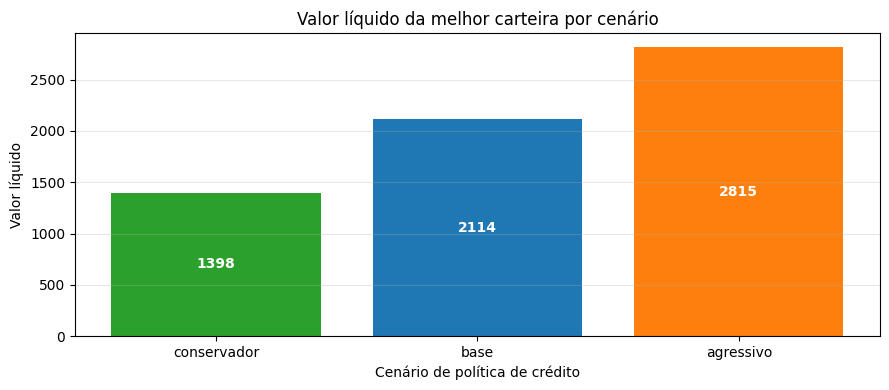

In [ ]:
plt.figure(figsize=(9, 4))
barras = plt.bar(
    resultado_sensibilidade["cenario"],
    resultado_sensibilidade["valor_liquido"],
    color=["tab:green", "tab:blue", "tab:orange"],
)
plt.title("Net value of the best portfolio by scenario")
plt.xlabel("Credit-policy scenario")
plt.ylabel("Net value")
plt.grid(axis="y", alpha=0.3)
plt.bar_label(barras, label_type='center', color='white', weight='bold', fmt='%.0f')
plt.tight_layout()
plt.show()


## 15. Main Limitations

This notebook is a didactic proof of concept. It demonstrates the complete QAOA workflow, but uses a small instance suitable for simulation and exact classical comparison. For larger problems, exhaustive search becomes impractical, the number of qubits grows with the number of customers, and parameter optimization becomes more difficult.

The exact conversion used here expands the cost function into products of Pauli $Z$ operators. For six customers this is executable, but it can produce up to $2^6 - 1 = 63$ non-constant terms. This construction should not be considered a scalable solution for real portfolios without a more economical QUBO/Ising formulation.

The QAOA result must also be interpreted carefully. The best **observed feasible** portfolio may differ from the **most frequent** measured state. Because this instance has only 64 states and uses 4,000 measurements, a large portion of the solution space can be sampled; therefore, the final table reports these two concepts separately.

Finally, penalties that are too small may allow infeasible portfolios, while penalties that are too large may dominate the cost function and make optimization more difficult. Credit-policy calibration is as important as the choice of quantum parameters.

## 16. Conclusion

This notebook implements QCredit using Qiskit's `QAOAAnsatz`. The credit problem is formulated as a binary cost function, converted into a diagonal Hamiltonian with `SparsePauliOp`, and solved through a hybrid optimization cycle.

The final stage uses shot-based measurements and restricts post-processing to states actually observed. The comparison explicitly distinguishes the **exact classical reference optimum**, the **most frequent state measured by QAOA**, and the **best feasible portfolio observed in QAOA measurements**. Therefore, the conclusion does not depend on selecting a classical state that the experiment did not actually produce.

The project demonstrates, step by step, how a credit-decision problem can be modeled as combinatorial optimization within a QAOA workflow:

**classical problem → cost function → Hamiltonian → QAOA ansatz → optimization → measurements → business decision**

The notebook also makes its limitations explicit for larger and real-world applications.

## References

1. Brazil Quantum Camp. *Block 2, Lesson 4 — Quantum Optimization II*. Course notebook.
2. NordIQuEst Application Library. *Tutorial — Solving Flight Scheduling Optimization using QAOA*.
3. IBM Quantum Documentation. *QAOAAnsatz*.
4. IBM Quantum Documentation. *SparsePauliOp*.